# Doc Processor Categorization Demo

This notebook runs the `doc_processor` LangGraph parser, converts paragraph parser metadata into `TextAnnotation` objects, and renders a **Parser Category Review** HTML preview.

By the end you should have:

1. A parsed `DocIR` with `paragraph.meta.parser` category metadata.
2. A category count summary and color legend.
3. A saved HTML review file under `tests/results/doc_processor_categorization_demo/`.
4. An inline iframe preview of the highlighted document.
    

## 1. Setup

Run this notebook from either the repository root or `apps/backend/doc_processor`. The path detection below finds the local package and sample documents.
    

In [1]:
from __future__ import annotations

from collections import Counter
from html import escape
from pathlib import Path
import sys

from IPython.display import HTML, display


def find_doc_processor_project(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "src" / "doc_processor").exists():
            return candidate
        nested = candidate / "apps" / "backend" / "doc_processor"
        if (nested / "pyproject.toml").exists() and (nested / "src" / "doc_processor").exists():
            return nested
    raise RuntimeError("Could not find apps/backend/doc_processor project directory.")


PROJECT_DIR = find_doc_processor_project(Path.cwd().resolve())
SRC_DIR = PROJECT_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

TESTS_DIR = PROJECT_DIR / "tests"
DOC_SAMPLES = TESTS_DIR / "doc_samples" / "new_test"
OUTPUT_DIR = TESTS_DIR / "results" / "doc_processor_categorization_demo"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from doc_processor import ParagraphCategory, ParserConfig, RelevanceMode, run_parser
from doc_processor.api import DocumentInput, TextAnnotation, render_review_html


def show_html(html: str, *, height: int = 760) -> None:
    display(
        HTML(
            f'<iframe srcdoc="{escape(html, quote=True)}" '
            f'width="100%" height="{height}" '
            'style="border:1px solid #d0d7de; border-radius:6px; background:#fff;"></iframe>'
        )
    )


PROJECT_DIR, DOC_SAMPLES, OUTPUT_DIR
    

(PosixPath('/home/maxjo/Work/LAS-system/apps/backend/doc_processor'),
 PosixPath('/home/maxjo/Work/LAS-system/apps/backend/doc_processor/tests/doc_samples/new_test'),
 PosixPath('/home/maxjo/Work/LAS-system/apps/backend/doc_processor/tests/results/doc_processor_categorization_demo'))

## 2. Choose a Sample Document

The default sample is an HWPX contract. Change `SAMPLE_DOC` to another file in `tests/doc_samples/new_test/` if you want to compare parser behavior.
    

In [2]:
SAMPLE_DOC = DOC_SAMPLES / "01. 대중문화예술분야 연습생 표준계약서.hwpx"
# SAMPLE_DOC = DOC_SAMPLES / "02. 청소년 대중문화예술인 표준 부속합의서.hwpx"
# SAMPLE_DOC = DOC_SAMPLES / "style_test_sample.docx"

assert SAMPLE_DOC.exists(), SAMPLE_DOC
SAMPLE_DOC
    

PosixPath('/home/maxjo/Work/LAS-system/apps/backend/doc_processor/tests/doc_samples/new_test/01. 대중문화예술분야 연습생 표준계약서.hwpx')

## 3. Run The LangGraph Parser

`run_parser(...)` builds and invokes the parser graph. The default settings below avoid external LLM calls so the notebook is easier to run locally. Set `USE_LLM_REVIEW = True` when the required LLM credentials are configured and you want boundary/label review.
    

In [9]:
USE_LLM_REVIEW = True

parser_state = run_parser(
    SAMPLE_DOC,
    config=ParserConfig(
        relevance_mode=RelevanceMode.KEYWORD_THEN_LLM if USE_LLM_REVIEW else RelevanceMode.DISABLED,
        boundary_review_enabled=USE_LLM_REVIEW,
        label_review_enabled=USE_LLM_REVIEW,
        langfuse_enabled=True,
    ),
)

parser_doc = parser_state.working_doc
parser_result = parser_state.parser_result
assert parser_doc is not None
assert parser_result is not None

{
    "accepted": parser_result.accepted,
    "reason": parser_result.reason,
    "clause_count": parser_result.clause_count,
    "subclause_count": parser_result.subclause_count,
    "notes": list(parser_result.notes),
}
    

2026-05-06 17:56:46,274 | INFO | structure analysis run start source=/home/maxjo/Work/LAS-system/apps/backend/doc_processor/tests/doc_samples/new_test/01. 대중문화예술분야 연습생 표준계약서.hwpx
2026-05-06 17:56:46,358 | INFO | [structure_analysis.load_document] start
2026-05-06 17:56:46,368 | INFO | [structure_analysis.load_document] done goto=screen_relevance
2026-05-06 17:56:46,380 | INFO | [structure_analysis.screen_relevance] start
2026-05-06 17:56:46,382 | INFO | [structure_analysis.screen_relevance] done goto=regex_analysis
2026-05-06 17:56:46,383 | INFO | [structure_analysis.regex_analysis] start
2026-05-06 17:56:46,385 | INFO | [structure_analysis.regex_analysis] done goto=llm_analysis
2026-05-06 17:56:46,388 | INFO | [structure_analysis.llm_analysis] start
2026-05-06 17:56:46,389 | INFO | [structure_analysis.llm_analysis] dispatching boundary batch review (25 suspects)
2026-05-06 17:56:46,389 | INFO | [structure_analysis.llm_analysis] done goto=boundary_llm_batch
2026-05-06 17:56:46,392 | IN

{'accepted': True,
 'reason': 'Parser clause parsing completed.',
 'clause_count': 13,
 'subclause_count': 40,
 'notes': ["Detected clause rule 'article' and subclause rule 'circled'."]}

## 4. Convert Parser Metadata To Review Annotations

The parser writes per-paragraph metadata to `paragraph.meta.parser`. This cell maps those categories/spans into `TextAnnotation` payloads that the HTML renderer can highlight.
    

In [10]:
PARSER_CATEGORY_COLORS = {
    ParagraphCategory.TITLE: "#D9EAD3",
    ParagraphCategory.PREAMBLE: "#FFF2CC",
    ParagraphCategory.CLAUSE_HEADING: "#F4CCCC",
    ParagraphCategory.CLAUSE_BODY: "#FCE5CD",
    ParagraphCategory.SUBCLAUSE_HEADING: "#D9D2E9",
    ParagraphCategory.SUBCLAUSE_BODY: "#CFE2F3",
    ParagraphCategory.INPUT_BLOCK: "#D0E0E3",
    ParagraphCategory.APPENDIX: "#EAD1DC",
    ParagraphCategory.HEADER: "#EFEFEF",
    ParagraphCategory.FOOTER: "#EFEFEF",
    ParagraphCategory.OTHER: "#E6E6E6",
    ParagraphCategory.BOUNDARY_SUSPECT: "#F9CB9C",
}


def parser_category_label(category: ParagraphCategory | None) -> str:
    if category is None:
        return "Unlabeled"
    return category.value.replace("_", " ").title()


def parser_category_color(category: ParagraphCategory | None) -> str:
    if category is None:
        return "#E6E6E6"
    return PARSER_CATEGORY_COLORS.get(category, "#E6E6E6")


def occurrence_index_for_span(text: str, selected_text: str, start: int) -> int | None:
    matches = []
    search_from = 0
    while True:
        index = text.find(selected_text, search_from)
        if index < 0:
            break
        matches.append(index)
        search_from = index + 1
    if not matches:
        raise ValueError(f"Could not find {selected_text!r} in paragraph text.")
    occurrence_index = matches.index(start)
    return occurrence_index if len(matches) > 1 else None


def note_from_parser_meta(parser_meta, *, category: ParagraphCategory | None = None) -> str:
    note_parts = []
    if category is not None:
        note_parts.append(f"category={category.value}")
    if parser_meta.clause_no:
        note_parts.append(f"clause={parser_meta.clause_no}")
    if parser_meta.subclause_no:
        note_parts.append(f"subclause={parser_meta.subclause_no}")
    if parser_meta.boundary_suspect:
        note_parts.append("boundary_suspect=true")
    return " | ".join(note_parts)


def parser_annotations_from_doc(doc):
    annotations = []
    skipped = []
    for paragraph in doc.paragraphs:
        parser_meta = paragraph.meta.parser if paragraph.meta and paragraph.meta.parser else None
        if parser_meta is None or not paragraph.text.strip():
            continue
        if paragraph.tables or paragraph.images:
            skipped.append(paragraph.node_id)
            continue

        if parser_meta.spans:
            for span in parser_meta.spans:
                selected_text = paragraph.text[span.start:span.end]
                if not selected_text:
                    continue
                annotations.append(
                    TextAnnotation(
                        target_kind="paragraph",
                        target_id=paragraph.node_id,
                        selected_text=selected_text,
                        occurrence_index=occurrence_index_for_span(paragraph.text, selected_text, span.start),
                        label=parser_category_label(span.kind),
                        color=parser_category_color(span.kind),
                        note=note_from_parser_meta(parser_meta, category=span.kind),
                    )
                )
            continue

        if parser_meta.category is None:
            continue
        annotations.append(
            TextAnnotation(
                target_kind="paragraph",
                target_id=paragraph.node_id,
                label=parser_category_label(parser_meta.category),
                color=parser_category_color(parser_meta.category),
                note=note_from_parser_meta(parser_meta, category=parser_meta.category),
            )
        )
    return annotations, skipped


parser_annotations, skipped_mixed_content = parser_annotations_from_doc(parser_doc)
category_counts = Counter(annotation.label for annotation in parser_annotations)

{
    "annotation_count": len(parser_annotations),
    "category_counts": dict(sorted(category_counts.items())),
    "skipped_mixed_content_paragraph_count": len(skipped_mixed_content),
    "skipped_mixed_content_examples": skipped_mixed_content[:10],
}
    

{'annotation_count': 81,
 'category_counts': {'Appendix': 2,
  'Clause Body': 1,
  'Clause Heading': 15,
  'Input Block': 15,
  'Other': 1,
  'Preamble': 3,
  'Subclause Body': 2,
  'Subclause Heading': 40,
  'Title': 2},
 'skipped_mixed_content_paragraph_count': 1,
 'skipped_mixed_content_examples': ['p_70a5402160bbf4b7']}

## 5. Display The Category Legend

The legend uses the same colors as the annotations that will be rendered into the document preview.
    

In [11]:
def category_legend_html(counts: Counter) -> str:
    rows = []
    for category, color in PARSER_CATEGORY_COLORS.items():
        label = parser_category_label(category)
        rows.append(
            "<tr>"
            f"<td><span style='display:inline-block;width:14px;height:14px;background:{color};border:1px solid #888;'></span></td>"
            f"<td style='padding:4px 10px 4px 6px;'>{label}</td>"
            f"<td style='text-align:right;padding:4px 0;'>{counts.get(label, 0)}</td>"
            "</tr>"
        )
    return """
    <div style='font-family:system-ui, sans-serif; max-width:480px;'>
      <h3 style='margin:0 0 8px;'>Parser Category Legend</h3>
      <table style='border-collapse:collapse;'>%s</table>
    </div>
    """ % "".join(rows)


display(HTML(category_legend_html(category_counts)))
    

,Title,2
,Preamble,3
,Clause Heading,15
,Clause Body,1
,Subclause Heading,40
,Subclause Body,2
,Input Block,15
,Appendix,2
,Header,0
,Footer,0
,Other,1


## 6. Render And Display The Parser Category Review

`render_review_html(...)` resolves each annotation against the current `DocIR`. The resulting HTML is saved and displayed inline using an iframe.
    

In [12]:
review = render_review_html(
    document=DocumentInput(doc_ir=parser_doc),
    annotations=parser_annotations,
    title="Parser Category Review",
)

review_path = OUTPUT_DIR / f"{SAMPLE_DOC.stem}_parser_category_review.html"
review_path.write_text(review.html or "", encoding="utf-8")

{
    "ok": review.ok,
    "review_path": str(review_path.relative_to(PROJECT_DIR)),
    "resolved_annotation_count": len(review.resolved_annotations),
    "validation_issues": [issue.model_dump(mode="json") for issue in review.validation.issues],
}
    

{'ok': True,
 'review_path': 'tests/results/doc_processor_categorization_demo/01. 대중문화예술분야 연습생 표준계약서_parser_category_review.html',
 'resolved_annotation_count': 81,
 'validation_issues': []}

/home/maxjo/Work/LAS-system/apps/backend/doc_processor/.venv/lib/python3.13/site-packages/IPython/core/display.py:447: UserWarning: Consider using IPython.display.IFrame instead
  warnings.warn("Consider using IPython.display.IFrame instead")



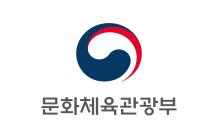

In [13]:
if review.ok and review.html:
    show_html(review.html, height=820)
else:
    display([issue.model_dump(mode="json") for issue in review.validation.issues])
    

## 7. Inspect Resolved Annotation Anchors

This small preview is useful when debugging whether the parser category spans resolved to the expected text.
    

In [14]:
resolved_preview = [
    annotation.model_dump(mode="json")
    for annotation in review.resolved_annotations[:20]
]
display(resolved_preview)
    

[{'target_kind': 'paragraph',
  'target_id': 'p_bfa4da5a775f2ffd',
  'selected_text': '[별표1]',
  'occurrence_index': None,
  'start': 0,
  'end': 5,
  'label': 'Appendix',
  'color': '#EAD1DC',
  'note': 'category=appendix'},
 {'target_kind': 'paragraph',
  'target_id': 'p_b137ee595f9f9767',
  'selected_text': '대중문화예술분야 연습생 표준계약서',
  'occurrence_index': None,
  'start': 0,
  'end': 18,
  'label': 'Title',
  'color': '#D9EAD3',
  'note': 'category=title'},
 {'target_kind': 'paragraph',
  'target_id': 'p_f91ab30f6c024f7d',
  'selected_text': '[대중문화예술기획업자]                   (이하\U000f0850기획업자\U000f0851라 한다)[와, 과]',
  'occurrence_index': None,
  'start': 0,
  'end': 51,
  'label': 'Preamble',
  'color': '#FFF2CC',
  'note': 'category=preamble'},
 {'target_kind': 'paragraph',
  'target_id': 'p_181bb4ee0bde7aef',
  'selected_text': '[연습생]                                 (이하\U000f0850연습생\U000f0851이라 한다)[는, 은] ',
  'occurrence_index': None,
  'start': 0,
  'end': 59,
  'label': 'Preamble',
  'c

## Exercise

Try one of these changes and rerun the notebook from step 2:

1. Switch `SAMPLE_DOC` to the second HWPX sample.
2. Set `USE_LLM_REVIEW = True` if your LLM credentials are configured.
3. Change one category color in `PARSER_CATEGORY_COLORS` and regenerate the HTML.

Expected result: the category counts and highlighted HTML should change, while the same `TextAnnotation` and `render_review_html(...)` flow stays intact.
    